# Risco relativo e odds ratio: antiviral precoce e internação por influenza

Journal Club · Pediatria

Artigo em discussão: Huang Y-N, Chang C-J, Dai Y-L, et al. *Early Antiviral Therapy in Pediatric Outpatients and Risk of Influenza-Related Hospitalization*. Pediatrics. 2026;158(3):e2025075020. [doi:10.1542/peds.2025-075020](https://doi.org/10.1542/peds.2025-075020)

**Objetivos de aprendizagem**

Ao final deste material, você será capaz de:

- Montar a tabela dois por dois de um artigo e calcular, a partir dela, risco, risco relativo, odds e odds ratio.
- Explicar por que um estudo caso-controle clássico estima odds ratio e não risco.
- Decidir, com um critério explícito, quando um odds ratio pode ser lido como risco relativo, e convertê-lo de forma aproximada.
- Distinguir associação bruta de associação ajustada e interpretar o E-value.
- Traduzir um efeito relativo em número necessário para tratar, para um risco basal especificado.

## 1. Introdução

Uma criança de 3 anos chega ao pronto-socorro em junho com 30 horas de febre, tosse e teste rápido positivo para influenza A. Está em bom estado geral e não tem comorbidades. A pergunta clínica é se iniciar oseltamivir agora reduz a chance de ela ser internada nos próximos dias.

Um estudo multicêntrico publicado na *Pediatrics* examinou essa questão em hospitais do norte de Taiwan, entre 2020 e 2023 [1]. O abstract afirma que o antiviral iniciado em até 48 horas do início dos sintomas "foi associado a um risco 81% menor de internação (aOR 0,19; IC 95% 0,14-0,27)".

Na discussão do caso, duas colegas chegam a conclusões opostas. A primeira sustenta que o antiviral reduz em 81% o risco de internar e que, portanto, toda criança com influenza deveria recebê-lo. A segunda responde que o estudo é um caso-controle, que nesse desenho não se pode falar em risco, e que o número do abstract nada diz sobre a criança à nossa frente.

Para decidir entre as duas, é preciso responder a quatro perguntas. O que mede um odds ratio de 0,19? Em que condições ele pode ser lido como redução de risco? O desenho deste estudo permite estimar risco? E quantas crianças como esta precisariam receber o antiviral para evitar uma internação?

O material percorre os conceitos na ordem em que o caso os exige: a tabela dois por dois (seção 2), risco e risco relativo (3), odds e odds ratio (4), o estudo caso-controle (5), a suposição do desfecho raro (6), a conversão aproximada de odds ratio em risco relativo (7), confundimento (8), E-value (9) e número necessário para tratar (10). A seção 11 volta à decisão e a seção 12 lê criticamente o desenho do estudo; os exercícios estão na seção 14 e suas soluções, na seção 15. Os blocos de código reproduzem cada número a partir das tabelas publicadas do artigo; não é preciso programar para acompanhar o texto.

Os dois blocos abaixo preparam o ambiente: bibliotecas, estilo dos gráficos e duas funções escritas para este material.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter, FixedLocator

# Palette: color is an extra layer; line style, marker, and fill carry the meaning
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY, INK, INK2 = "#9a9993", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "xtick.color": INK2, "ytick.color": INK2,
})


def br(x, nd=2):
    # Format a number with a decimal comma, as in the text
    return f"{x:.{nd}f}".replace(".", ",")

In [2]:
def dot_grid(ax, n_total, n_event, ncols=40, size=38, title=None, ymin=None):
    # Icon array: one marker per child; events are filled, non-events are hollow
    idx = np.arange(n_total)
    x, y = idx % ncols, -(idx // ncols)
    ev = idx < n_event
    ax.scatter(x[ev], y[ev], s=size, color=ORANGE, edgecolors=INK, linewidths=0.4)
    ax.scatter(x[~ev], y[~ev], s=size, facecolors="none", edgecolors=GRAY, linewidths=0.9)
    ax.set_xlim(-1, ncols)
    ax.set_ylim((y.min() if ymin is None else ymin) - 1, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left", fontsize=12, color=INK)


def plain_log_x(ax, ticks):
    # Log x-axis with decimal-comma tick labels and no minor labels
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{t:g}".replace(".", ",") for t in ticks])
    ax.xaxis.set_minor_formatter(NullFormatter())

## 2. Tabela dois por dois

Antes de comparar os grupos, é preciso definir quem entra em cada numerador e em cada denominador.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Tabela dois por dois</b><br>Uma tabela dois por dois classifica as observações segundo duas variáveis, cada uma com duas categorias, e apresenta a contagem em cada uma das quatro combinações [2].</div>

Neste material a exposição fica nas linhas e o desfecho nas colunas, com "sim" antes de "não". Outras orientações são possíveis; leia sempre os rótulos. A unidade de observação é uma criança menor de 18 anos com influenza confirmada laboratorialmente, atendida nos hospitais do estudo [1]. A exposição é o antiviral iniciado em até 48 horas do início dos sintomas. O grupo de comparação reúne as crianças que receberam o antiviral depois de 48 horas e as que não o receberam; o artigo trata as duas situações como uma única categoria. O desfecho é a internação (ou o óbito) relacionada à influenza em até 14 dias do início dos sintomas.

As contagens vêm da Tabela 1 do artigo [1]. Entre os 354 internados, 194 receberam o antiviral precoce, 156 o receberam tarde e 4 não o receberam, o que dá 160 na categoria de comparação. Entre os 1.138 não internados, os números são 1.012, 113 e 13, o que dá 126.

| Antiviral | Internado | Não internado | Total |
|---|---|---|---|
| Precoce (até 48 h) | a = 194 | b = 1.012 | 1.206 |
| Tardio ou nenhum | c = 160 | d = 126 | 286 |
| Total | 354 | 1.138 | 1.492 |

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Tabela 1.</b> Antiviral precoce e internação por influenza em 14 dias, a partir da Tabela 1 de Huang et al. [1]. As letras a, b, c e d são a notação usada em todo o material.</div>

O bloco abaixo registra as quatro células e reconstrói a tabela com os totais.

In [3]:
a, b = 194, 1012   # early antiviral: hospitalized, not hospitalized
c, d = 160, 126    # late or no antiviral: hospitalized, not hospitalized

tab = pd.DataFrame({"Internado": [a, c], "Não internado": [b, d]},
                   index=["Precoce (até 48 h)", "Tardio ou nenhum"])
tab["Total"] = tab.sum(axis=1)
tab.loc["Total"] = tab.sum()
tab

,Internado,Não internado,Total
Precoce (até 48 h),194,1012,1206
Tardio ou nenhum,160,126,286
Total,354,1138,1492


A tabela reproduz os totais do artigo: 354 internados, 1.138 não internados e 1.492 crianças. A Figura 1 mostra cada criança como um ponto.

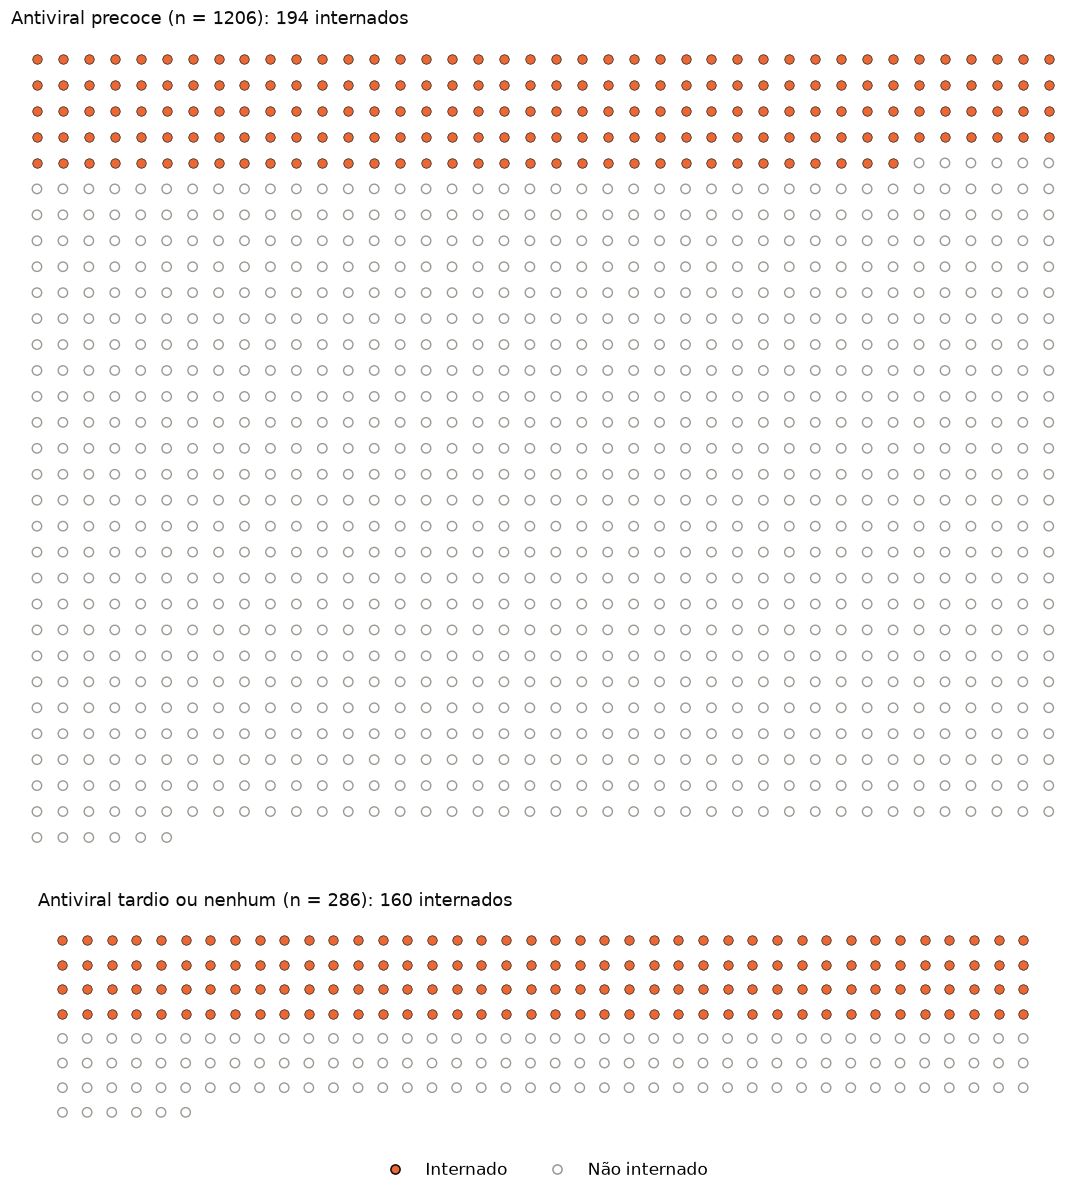

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11),
                               gridspec_kw={"height_ratios": [31, 8]})
dot_grid(ax1, a + b, a, title=f"Antiviral precoce (n = {a + b}): {a} internados")
dot_grid(ax2, c + d, c, title=f"Antiviral tardio ou nenhum (n = {c + d}): {c} internados")
handles = [Line2D([], [], marker="o", ls="", color=ORANGE, mec=INK, label="Internado"),
           Line2D([], [], marker="o", ls="", mfc="none", mec=GRAY, label="Não internado")]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 1.</b> As 1.492 crianças do estudo, uma por ponto. Pontos cheios: internadas; pontos vazados: não internadas. Painel superior: antiviral em até 48 horas; painel inferior: antiviral depois de 48 horas ou nenhum.</div>

No grupo do antiviral precoce os internados são minoria; no grupo de comparação, mais da metade. A impressão é de um efeito grande. Resta saber se essas proporções representam o risco de internação de uma criança com influenza, pergunta que as seções 3 e 5 respondem.

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 1 (seção 14). Atenção à posição de exposição e desfecho na tabela.</div>

## 3. Risco e risco relativo

A primeira colega fala em "risco". O termo tem um significado preciso, e é por ele que começamos.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Risco</b><br>O risco é a proporção de pessoas de um grupo, inicialmente livres do desfecho, que o desenvolvem em um período especificado. Também é chamado incidência cumulativa [2,3].</div>

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Risco relativo</b><br>O risco relativo (RR), também chamado razão de riscos, é o risco no grupo exposto dividido pelo risco no grupo de comparação, para o mesmo desfecho e o mesmo horizonte de tempo: $\mathrm{RR}=p_1/p_0$, desde que $p_0>0$ [2,3].</div>

Com $p_1$ para o grupo exposto e $p_0$ para o de comparação, a tabela dá

$$p_1=\frac{a}{a+b}=\frac{194}{1.206}=0{,}161 \qquad p_0=\frac{c}{c+d}=\frac{160}{286}=0{,}559$$

$$\mathrm{RR}=\frac{0{,}161}{0{,}559}=0{,}29$$

As crianças que receberam o antiviral precoce tiveram 0,29 vez o risco observado de internação das demais. O denominador de cada risco é o grupo inteiro: 194 dividido por todas as 1.206 crianças expostas. Dividir 194 por 354 responderia a outra pergunta, a proporção de internados que recebeu o antiviral precoce.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Redução relativa do risco</b><br>Quando $p_1<p_0$, a redução relativa do risco é a diferença de riscos a favor do grupo exposto dividida pelo risco no grupo de comparação: $\mathrm{RRR}=(p_0-p_1)/p_0=1-\mathrm{RR}$ [2].</div>

Aqui, $\mathrm{RRR}=1-0{,}29=0{,}71$, ou 71%. Esse cálculo supõe que as proporções da tabela sejam riscos, o que depende do desenho do estudo (seção 5). Uma razão, sozinha, também não informa a magnitude absoluta: riscos de 16% e 56% e riscos de 0,16% e 0,56% têm o mesmo RR, mas diferenças de 40 e de 0,4 pontos percentuais.

O bloco abaixo confirma os três números calculados à mão.

In [5]:
p1 = a / (a + b)          # risk among early-antiviral children
p0 = c / (c + d)          # risk in the comparison group
rr = p1 / p0

print(f"p1 = {a}/{a + b} = {br(p1, 3)}")
print(f"p0 = {c}/{c + d} = {br(p0, 3)}")
print(f"RR = {br(rr)}   RRR = {1 - rr:.0%}")

p1 = 194/1206 = 0,161
p0 = 160/286 = 0,559
RR = 0,29   RRR = 71%


Os valores coincidem com o cálculo manual: RR 0,29 e redução relativa de 71%. A Figura 2 mostra os mesmos riscos em grupos de 100 crianças.

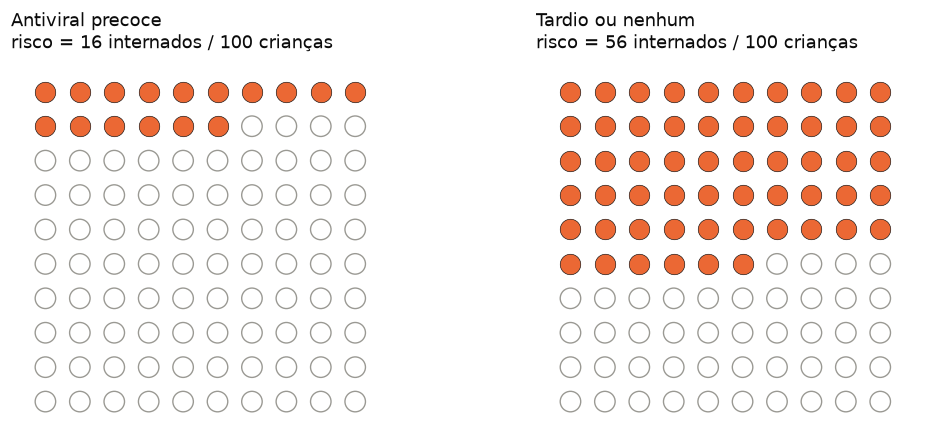

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, r, lab in zip(axes, [p1, p0], ["Antiviral precoce", "Tardio ou nenhum"]):
    k = round(r * 100)
    dot_grid(ax, 100, k, ncols=10, size=180,
             title=f"{lab}\nrisco = {k} internados / 100 crianças")
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 2.</b> Risco de internação em grupos de 100 crianças, com as proporções da Tabela 1 arredondadas. O risco compara os pontos cheios com todos os pontos do grupo.</div>

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 2 (seção 14). Confira que cada denominador é o grupo de exposição inteiro.</div>

## 4. Odds e odds ratio

O abstract não relata um risco relativo, e sim um odds ratio. Para entender por que os dois diferem, começamos pelo denominador de uma odds.

Uma proporção $p$ corresponde à odds $p/(1-p)$: o número de eventos é comparado com o de não eventos, e não com o total. Com risco de 0,5 a odds é 1; com risco de 0,75, é 3. A odds não é uma porcentagem e pode ser maior que 1.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Odds ratio</b><br>O odds ratio (OR) divide a odds do desfecho em um grupo pela odds no grupo de comparação. Numa tabela dois por dois com células positivas, é igual à razão dos produtos cruzados: $\mathrm{OR}=(a/b)/(c/d)=ad/(bc)$ [2,4].</div>

No grupo do antiviral precoce, a odds de internação é $194/1.012=0{,}192$; no grupo de comparação, $160/126=1{,}270$. Assim,

$$\mathrm{OR}=\frac{194\times126}{1.012\times160}=0{,}15$$

O valor coincide com o OR bruto da Tabela 2 do artigo, 0,15 (IC 95% 0,11-0,20) [1]. Risco e odds têm o mesmo numerador e diferem apenas no denominador:

| Medida | Numerador | Denominador |
|---|---|---|
| Risco | internados | todas as crianças do grupo |
| Odds | internados | apenas as crianças não internadas |

O RR foi 0,29 e o OR, 0,15. A proposição seguinte explica essa diferença sem recorrer a regra prática.

**Proposição 1 (odds ratio e risco relativo).** Se $0<p_0,p_1<1$, então

$$\mathrm{OR}=\mathrm{RR}\times\frac{1-p_0}{1-p_1}.$$

Quando $p_1<p_0$, tem-se $\mathrm{OR}<\mathrm{RR}<1$; quando $p_1>p_0$, $\mathrm{OR}>\mathrm{RR}>1$. Se os dois riscos tendem a zero, a razão $\mathrm{OR}/\mathrm{RR}$ tende a 1.

*Demonstração.* Divida $p_1/(1-p_1)$ por $p_0/(1-p_0)$ e reagrupe os fatores: $\mathrm{OR}=(p_1/p_0)\times(1-p_0)/(1-p_1)$. Se $p_1<p_0$, então $1-p_0<1-p_1$ e o fator multiplicador é menor que 1, o que afasta o OR de 1 para baixo; invertendo a desigualdade, o fator passa de 1. Quando os dois riscos tendem a zero, numerador e denominador do fator tendem a 1. ∎

O OR fica, portanto, mais longe de 1 do que o RR sempre que os riscos diferem. Neste estudo o fator é $(1-0{,}559)/(1-0{,}161)=0{,}53$, e $0{,}29\times0{,}53=0{,}15$. Uma propriedade adicional será usada na seção 5: transpor a tabela não altera $ad/(bc)$, de modo que o OR do desfecho entre expostos e não expostos é igual ao OR da exposição entre casos e controles.

O bloco abaixo calcula as odds, o OR e confere a Proposição 1 com os números do artigo.

In [7]:
odds1, odds0 = a / b, c / d
or_crude = odds1 / odds0
factor = (1 - p0) / (1 - p1)

print(f"odds1 = {br(odds1, 3)}   odds0 = {br(odds0, 3)}")
print(f"OR = ad/(bc) = {br(or_crude)}   (Tabela 2 do artigo: 0,15)")
print(f"RR x (1-p0)/(1-p1) = {br(rr)} x {br(factor)} = {br(rr * factor)}")

odds1 = 0,192   odds0 = 1,270
OR = ad/(bc) = 0,15   (Tabela 2 do artigo: 0,15)
RR x (1-p0)/(1-p1) = 0,29 x 0,53 = 0,15


As duas vias levam ao mesmo OR de 0,15, e o fator 0,53 mostra que, neste estudo, o OR é cerca de metade do RR. A Figura 3 mostra por quê: a odds cresce muito mais depressa que o risco quando o desfecho é comum.

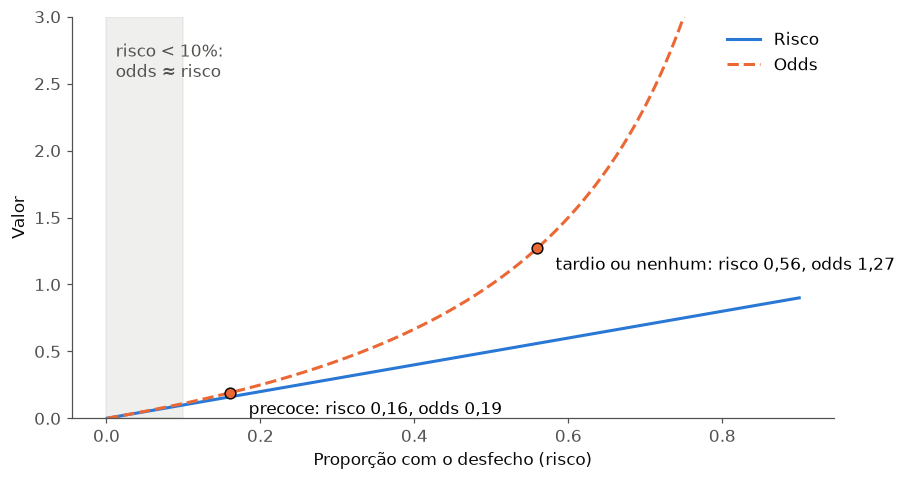

In [8]:
p = np.linspace(0.001, 0.9, 300)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(p, p, color=BLUE, lw=2, ls="-", label="Risco")
ax.plot(p, p / (1 - p), color=ORANGE, lw=2, ls="--", label="Odds")
ax.axvspan(0, 0.10, color=GRAY, alpha=0.15)
ax.text(0.012, 2.55, "risco < 10%:\nodds ≈ risco", color=INK2)
for r_, lab in [(p1, "precoce"), (p0, "tardio ou nenhum")]:
    ax.plot([r_], [r_ / (1 - r_)], "o", color=ORANGE, mec=INK, ms=7)
    ax.annotate(f"{lab}: risco {br(r_)}, odds {br(r_ / (1 - r_))}",
                (r_, r_ / (1 - r_)), xytext=(12, -14), textcoords="offset points")
ax.set_ylim(0, 3)
ax.set_xlabel("Proporção com o desfecho (risco)")
ax.set_ylabel("Valor")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 3.</b> Risco (linha contínua) e odds correspondente (linha tracejada). Abaixo de cerca de 10% as duas curvas praticamente coincidem; acima disso a odds se afasta rapidamente. Os pontos marcam os dois grupos do estudo.</div>

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 3 (seção 14). Use a Proposição 1 para explicar a diferença entre OR e RR.</div>

## 5. Estudo caso-controle

A segunda colega objeta que o estudo é um caso-controle. Para avaliar a objeção, é preciso saber o que esse desenho permite estimar.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Estudo caso-controle</b><br>Um estudo caso-controle seleciona casos com o desfecho de interesse e controles da mesma população de origem e compara a exposição entre eles. O esquema de amostragem dos controles determina qual comparação populacional o odds ratio resultante pode estimar [5,6].</div>

No desenho clássico, todos os casos são incluídos e apenas uma fração dos não casos é amostrada. O número de controles por caso (1:1, 1:4, 1:10) é uma decisão do pesquisador. A proporção de casos na amostra passa, então, a refletir essa decisão, e não a frequência do desfecho na população.

**Proposição 2 (as frações de amostragem se cancelam no odds ratio).** Suponha que os casos dos dois grupos de exposição sejam retidos na mesma proporção $s_1>0$ e os não casos, na mesma proporção $s_0>0$. As contagens proporcionais preservam a razão dos produtos cruzados, mesmo quando $s_1\neq s_0$.

*Demonstração.* As células passam a ser $s_1a$, $s_0b$, $s_1c$ e $s_0d$. A razão dos produtos cruzados é

$$\frac{(s_1a)(s_0d)}{(s_0b)(s_1c)}=\frac{ad}{bc}.$$

A proporção na linha, porém, passa a ser $s_1a/(s_1a+s_0b)$, em geral diferente de $a/(a+b)$ quando as frações diferem. ∎

A proposição explica a objeção da segunda colega: num caso-controle clássico, as proporções das linhas não são riscos, e o RR calculado a partir delas não tem significado populacional. O OR, ao contrário, sobrevive à amostragem.

Para ver isso com os números do artigo, mantemos os 354 internados e mudamos apenas o número de controles, preservando a proporção de expostos entre eles ($1.012/1.138=88{,}9\%$). O bloco abaixo calcula o "RR" e o OR para várias razões de controles por caso.

In [9]:
p_exp_ctrl = b / (b + d)
rows = []
for ratio in [1, 1138 / 354, 10, 50, 200]:
    n_ctrl = round(354 * ratio)
    b_s = p_exp_ctrl * n_ctrl          # sampled exposed controls
    d_s = n_ctrl - b_s                 # sampled unexposed controls
    rows.append({"controles por caso": "1:" + br(ratio, 1).replace(",0", ""),
                 "controles": n_ctrl,
                 "'RR' da amostra": br((a / (a + b_s)) / (c / (c + d_s)), 3),
                 "OR": br((a * d_s) / (b_s * c), 3),
                 "% de casos na amostra": br(100 * 354 / (354 + n_ctrl), 1)})
pd.DataFrame(rows)

,controles por caso,controles,'RR' da amostra,OR,% de casos na amostra
0,1:1,354,"0,475","0,151","50,0"
1,"1:3,2",1138,"0,288","0,151","23,7"
2,1:10,3540,"0,200","0,151","9,1"
3,1:50,17700,"0,161","0,151","2,0"
4,1:200,70800,"0,154","0,151","0,5"


O OR permanece em 0,151 em todas as linhas, enquanto o "RR" varia de 0,475 a 0,154 conforme o número de controles. A proporção de casos na amostra cai de 50% para 0,5% sem que nenhuma criança tenha ficado menos doente. A Figura 4 mostra a mesma relação de forma contínua.

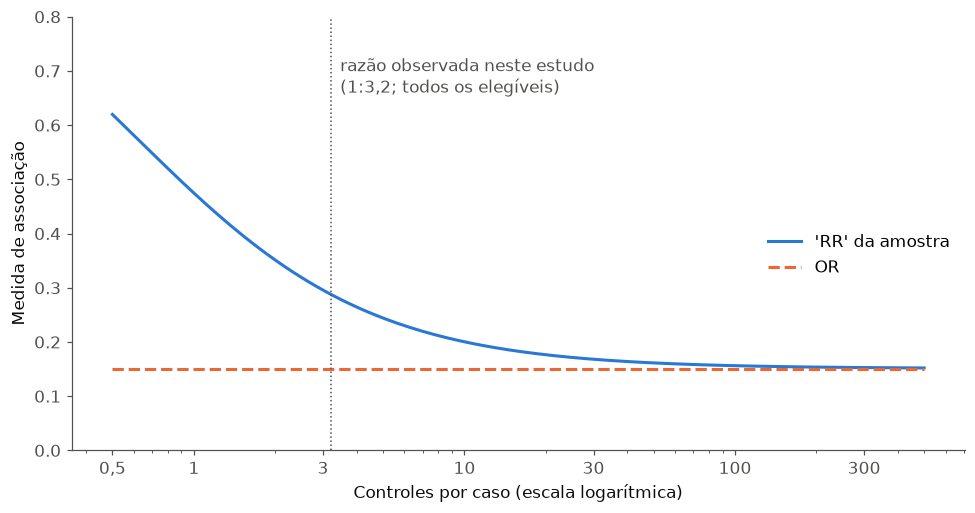

In [10]:
ratios = np.geomspace(0.5, 500, 200)
n_ctrl = 354 * ratios
b_s, d_s = p_exp_ctrl * n_ctrl, (1 - p_exp_ctrl) * n_ctrl
rr_line = (a / (a + b_s)) / (c / (c + d_s))
or_line = (a * d_s) / (b_s * c)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(ratios, rr_line, color=BLUE, lw=2, ls="-", label="'RR' da amostra")
ax.plot(ratios, or_line, color=ORANGE, lw=2, ls="--", label="OR")
ax.axvline(1138 / 354, color=INK2, ls=":", lw=1)
ax.text(1138 / 354 * 1.08, 0.66, "razão observada neste estudo\n(1:3,2; todos os elegíveis)",
        color=INK2)
plain_log_x(ax, [0.5, 1, 3, 10, 30, 100, 300])
ax.set_ylim(0, 0.8)
ax.set_xlabel("Controles por caso (escala logarítmica)")
ax.set_ylabel("Medida de associação")
ax.legend(frameon=False, loc="center right", bbox_to_anchor=(1, 0.45))
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 4.</b> Com os 354 casos fixos, o 'RR' calculado na amostra (linha contínua) depende do número de controles; o OR (linha tracejada) não se altera. A linha pontilhada marca a razão observada no estudo.</div>

### Este estudo é um caso-controle clássico?

O artigo se descreve como caso-controle pareado, mas o Methods informa que "all eligible cases were matched to all eligible controls" [1]. O fluxograma mostra 1.539 crianças com influenza confirmada, 1.531 elegíveis e 1.492 analisadas. Ninguém escolheu a razão de 1:3,2; ela é a proporção natural de internados entre todas as crianças elegíveis.

Na prática, portanto, a amostra é a coorte hospitalar inteira, analisada com ferramentas de caso-controle. As proporções das linhas da Tabela 1 são riscos nessa coorte, e o RR de 0,29 é uma estimativa legítima para ela. A objeção da segunda colega vale para o desenho clássico, mas não se aplica integralmente a este estudo.

Isso não torna os 56% de internação no grupo de comparação representativos da criança do consultório. São crianças testadas para influenza em hospitais, provavelmente mais graves, em média, do que as atendidas na atenção primária. O limite aqui não é o desenho, e sim a seleção da população, tema que volta na seção 12.

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 4 (seção 14). Pergunte-se quem decidiu o número de controles.</div>

## 6. Suposição do desfecho raro

A leitura da primeira colega, OR de 0,19 como "81% menos risco", só é aceitável em uma situação específica.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Suposição do desfecho raro</b><br>A suposição do desfecho raro estabelece que, quando o risco do desfecho é pequeno nos dois grupos comparados da população de origem, o odds ratio se aproxima do risco relativo [2,4].</div>

A Proposição 1 mostra o que "pequeno" significa. A distorção é $\mathrm{OR}/\mathrm{RR}=(1-p_0)/(1-p_1)$, e não há um corte universal que garanta uma precisão fixa. Os cortes mais usados são atalhos: menos de 10% é a regra dos livros-texto; 15% é o limite a partir do qual VanderWeele e Ding recomendam converter o OR antes de calcular o E-value (seção 9). Um critério explícito é calcular o fator $(1-p_0)/(1-p_1)$: se ele ficar entre 0,9 e 1,1, o OR difere do RR em menos de 10%.

Duas consequências merecem atenção. Primeira, o risco precisa ser pequeno nos dois grupos, e não apenas no total. Segunda, em efeitos nocivos o desfecho precisa ser ainda mais raro, porque o risco dos expostos é maior que o basal. O bloco abaixo calcula o fator em cenários típicos e, na última linha, com os dados do artigo.

In [11]:
scenarios = [(0.05, 0.3), (0.10, 0.3), (0.10, 3.0), (0.20, 2.0), (p0, rr)]
rows = []
for p0_s, rr_s in scenarios:
    p1_s = p0_s * rr_s
    f = (1 - p0_s) / (1 - p1_s)
    rows.append({"p0": f"{br(100 * p0_s, 0)}%", "RR": br(rr_s),
                 "p1": f"{br(100 * p1_s, 1)}%", "OR": br(rr_s * f),
                 "OR/RR": br(f), "distância entre OR e RR": f"{abs(1 - f):.0%}"})
tab_rare = pd.DataFrame(rows, index=["", "", "", "", "este estudo"])
tab_rare

,p0,RR,p1,OR,OR/RR,distância entre OR e RR
,5%,"0,30","1,5%","0,29","0,96",4%
,10%,"0,30","3,0%","0,28","0,93",7%
,10%,"3,00","30,0%","3,86","1,29",29%
,20%,"2,00","40,0%","2,67","1,33",33%
este estudo,56%,"0,29","16,1%","0,15","0,53",47%


<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Tabela 2.</b> Distância entre OR e RR em cinco cenários. A última linha usa os riscos da coorte do estudo: o OR corresponde a cerca de metade do RR.</div>

Com risco basal de 5% e efeito protetor, o OR se afasta apenas 4% do RR. Com risco basal de 10% e RR de 3, a distância já é de 29%. Neste estudo, com 56% de internação no grupo de comparação, o OR é 47% menor que o RR. As Figuras 5 e 6 mostram o fenômeno de forma contínua.

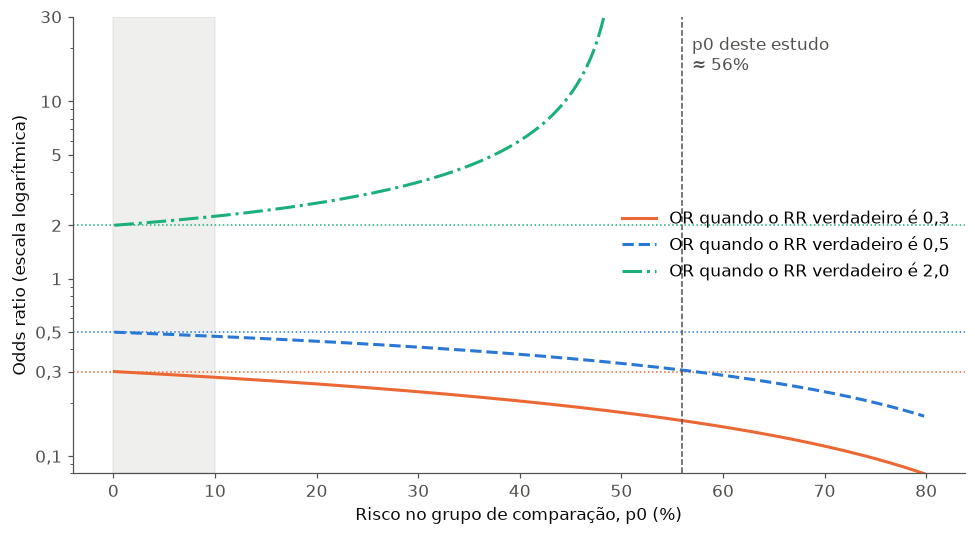

In [12]:
p0g = np.linspace(0.001, 0.8, 400)
fig, ax = plt.subplots(figsize=(9, 5))
for rr_true, col, ls in [(0.3, ORANGE, "-"), (0.5, BLUE, "--"), (2.0, AQUA, "-.")]:
    pp = p0g[p0g < min(0.8, 0.98 / rr_true)]   # exposed risk must stay below 1
    ax.plot(pp * 100, rr_true * (1 - pp) / (1 - rr_true * pp), color=col, lw=2, ls=ls,
            label=f"OR quando o RR verdadeiro é {br(rr_true, 1)}")
    ax.axhline(rr_true, color=col, lw=1, ls=":")
ax.axvspan(0, 10, color=GRAY, alpha=0.15)
ax.axvline(p0 * 100, color=INK2, ls="--", lw=1)
ax.text(p0 * 100 + 1, 15, f"p0 deste estudo\n≈ {p0:.0%}", color=INK2)
ax.set_yscale("log")
ax.set_ylim(0.08, 30)
ax.yaxis.set_major_locator(FixedLocator([0.1, 0.3, 0.5, 1, 2, 5, 10, 30]))
ax.set_yticklabels(["0,1", "0,3", "0,5", "1", "2", "5", "10", "30"])
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("Risco no grupo de comparação, p0 (%)")
ax.set_ylabel("Odds ratio (escala logarítmica)")
ax.legend(frameon=False, loc="center right")
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 5.</b> Odds ratio que se observaria para três valores fixos do RR verdadeiro (linhas pontilhadas horizontais), conforme o risco no grupo de comparação aumenta. Na faixa sombreada (menos de 10%) o OR praticamente coincide com o RR; à direita, afasta-se de 1.</div>

Um efeito protetor parece mais protetor e um efeito nocivo parece mais nocivo; o OR nunca fica mais perto de 1 do que o RR. A Figura 6 expressa a mesma distância em porcentagem.

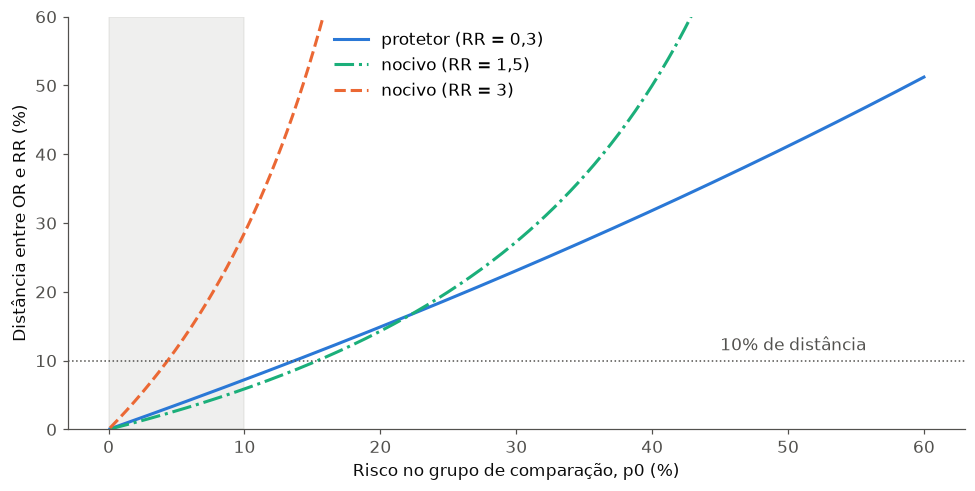

In [13]:
p0g = np.linspace(0.001, 0.6, 300)
fig, ax = plt.subplots(figsize=(9, 4.6))
for rr_true, col, ls, lab in [(0.3, BLUE, "-", "protetor (RR = 0,3)"),
                              (1.5, AQUA, "-.", "nocivo (RR = 1,5)"),
                              (3.0, ORANGE, "--", "nocivo (RR = 3)")]:
    pp = p0g[p0g * rr_true < 0.95]
    f = (1 - pp) / (1 - pp * rr_true)
    ax.plot(pp * 100, np.abs(1 - f) * 100, color=col, lw=2, ls=ls, label=lab)
ax.axhline(10, color=INK2, ls=":", lw=1)
ax.text(45, 11.5, "10% de distância", color=INK2)
ax.axvspan(0, 10, color=GRAY, alpha=0.15)
ax.set_ylim(0, 60)
ax.set_xlabel("Risco no grupo de comparação, p0 (%)")
ax.set_ylabel("Distância entre OR e RR (%)")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.28, 1.0))
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 6.</b> Distância percentual entre OR e RR. Com RR de 3, a distância passa de 10% antes de o risco basal chegar a 5%; com efeito protetor, perto de 13%.</div>

### Raro onde

O risco que importa é o da população de origem, e não o da amostra. Num caso-controle clássico a proporção de casos na amostra é definida pelo desenho (seção 5); o risco precisa vir de fonte externa, como incidência publicada, vigilância ou registro. Neste estudo a amostra coincide com a coorte hospitalar, e é possível verificar diretamente que o desfecho não é raro: 24% no total, 16% no grupo exposto e 56% no de comparação.

### Quando a suposição não é necessária

Nem todo caso-controle depende da suposição do desfecho raro. O que o OR estima depende de como os controles foram amostrados [5-7]:

| Amostragem dos controles | O OR estima | Exige desfecho raro? |
|---|---|---|
| Entre quem ainda estava em risco no momento de cada caso (densidade de incidência) | razão de taxas | Não |
| Da coorte inteira, no início do seguimento (caso-coorte) | risco relativo | Não |
| Entre quem terminou o seguimento sem o desfecho (cumulativa) | odds ratio | Sim, para ser lido como RR |

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Tabela 3.</b> O alvo do odds ratio segundo o esquema de amostragem dos controles [5-7]. O rótulo 'caso-controle', sozinho, não identifica a medida estimada.</div>

Knol e colaboradores examinaram 150 caso-controles publicados; dos 125 com casos incidentes, classificaram 105 como compatíveis com a leitura do OR como razão de taxas, pela forma como os controles foram amostrados [7]. Verificar apenas se o desfecho é raro, portanto, deixa de lado boa parte da questão de desenho. Ao ler um caso-controle, procure no Methods como os controles foram selecionados antes de decidir como interpretar o OR.

<div style="border:2px solid #1a1a19;border-radius:3px;padding:12px 16px;margin:16px 0;color:#111"><b>Armadilha: ler um odds ratio como redução de risco quando o desfecho é comum</b><br>Neste estudo, 56% das crianças do grupo de comparação foram internadas. Nessa situação, 'aOR 0,19' não equivale a '81% menos risco': o OR exagera o efeito e corresponde a um RR em torno de 0,35 (seção 7). Antes de traduzir um OR em linguagem de risco, verifique os riscos nos dois grupos da população de origem e calcule $(1-p_0)/(1-p_1)$.</div>

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 5 (seção 14). Calcule o fator nos dois cenários antes de responder.</div>

## 7. Conversão aproximada de odds ratio em risco relativo

Como a amostra é a coorte hospitalar inteira, o risco no grupo de comparação é conhecido, e o OR ajustado do artigo pode ser convertido em um RR aproximado.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Correção de Zhang e Yu</b><br>A correção de Zhang e Yu converte um odds ratio em risco relativo aproximado a partir do risco no grupo de comparação: $\mathrm{RR}\approx\mathrm{OR}/[(1-p_0)+p_0\cdot\mathrm{OR}]$ [8].</div>

**Proposição 3 (de OR para RR).** Se $0<p_0<1$ e $p_1=p_0\,\mathrm{RR}<1$, então $\mathrm{RR}=\mathrm{OR}/[(1-p_0)+p_0\,\mathrm{OR}]$.

*Demonstração.* Pela Proposição 1, $\mathrm{OR}=\mathrm{RR}(1-p_0)/(1-p_0\mathrm{RR})$. Multiplicando os dois lados por $(1-p_0\mathrm{RR})$, obtém-se $\mathrm{OR}-\mathrm{OR}\,p_0\mathrm{RR}=\mathrm{RR}(1-p_0)$. Passando o termo com RR para o lado direito, $\mathrm{OR}=\mathrm{RR}[(1-p_0)+p_0\mathrm{OR}]$. Dividindo pelo colchete, chega-se ao resultado. ∎

Com o OR ajustado de 0,19 e $p_0=0{,}559$:

$$\mathrm{RR}\approx\frac{0{,}19}{(1-0{,}559)+0{,}559\times0{,}19}=\frac{0{,}19}{0{,}547}=0{,}35$$

Aplicada aos limites do intervalo (0,14 e 0,27), a conversão dá 0,27 e 0,46. A redução relativa correspondente é de cerca de 65%, e não de 81%.

A identidade é exata para riscos brutos, mas aplicada a um OR ajustado ela é apenas uma aproximação: o $p_0$ bruto não é o risco basal condicional às covariáveis, e os intervalos convertidos tendem a ficar estreitos demais. McNutt e colaboradores mostraram esse viés e recomendaram estimar o RR diretamente, com regressão log-binomial ou de Poisson com variância robusta [9]. A conversão serve para ordem de grandeza, não para substituir essa análise.

O bloco abaixo reúne as quatro medidas com seus intervalos: OR e RR brutos, com intervalos pelo método do logaritmo, e o OR ajustado do artigo com sua conversão.

In [14]:
def zhang_yu(or_, p0_):
    return or_ / ((1 - p0_) + p0_ * or_)

z = 1.96
se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
se_log_rr = math.sqrt(1/a - 1/(a + b) + 1/c - 1/(c + d))
or_ci = [math.exp(math.log(or_crude) + s * z * se_log_or) for s in (-1, 1)]
rr_ci = [math.exp(math.log(rr) + s * z * se_log_rr) for s in (-1, 1)]
aor = (0.19, 0.14, 0.27)                      # adjusted OR from the article
rr_adj = [zhang_yu(v, p0) for v in aor]

res = pd.DataFrame([["OR bruto", or_crude, *or_ci],
                    ["OR ajustado (artigo)", *aor],
                    ["RR bruto", rr, *rr_ci],
                    ["RR aproximado do OR ajustado", *rr_adj]],
                   columns=["medida", "estimativa", "IC 95% inf", "IC 95% sup"])
res["redução relativa"] = (1 - res["estimativa"]).map("{:.0%}".format)
res.round(2)

,medida,estimativa,IC 95% inf,IC 95% sup,redução relativa
0,OR bruto,0.15,0.11,0.20,85%
1,OR ajustado (artigo),0.19,0.14,0.27,81%
2,RR bruto,0.29,0.24,0.34,71%
3,RR aproximado do OR ajustado,0.35,0.27,0.46,65%


O OR bruto calculado, 0,15 (IC 95% 0,11-0,20), reproduz o da Tabela 2 do artigo [1]. O RR bruto é 0,29 (IC 95% 0,24-0,34), e o RR aproximado a partir do OR ajustado é 0,35 (IC 95% 0,27-0,46). A Figura 7 compara as quatro estimativas.

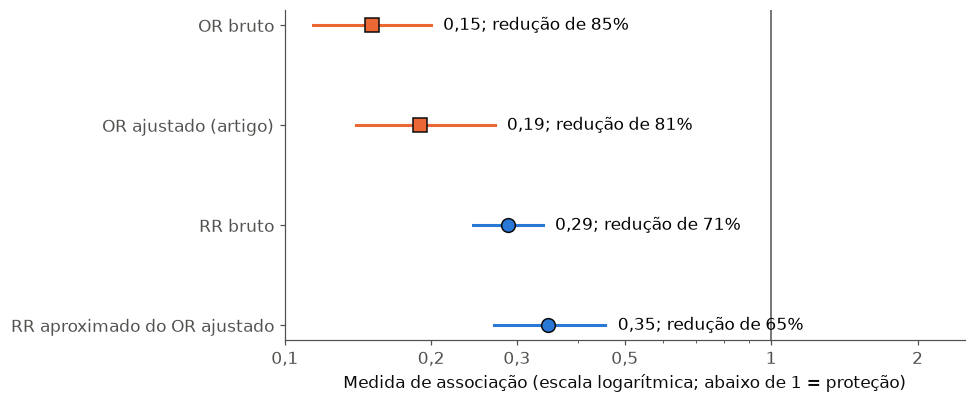

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.8))
styles = {"OR": ("s", ORANGE), "RR": ("o", BLUE)}
for i, row in res.iloc[::-1].reset_index(drop=True).iterrows():
    mk, col = styles[row["medida"][:2]]
    ax.plot([row["IC 95% inf"], row["IC 95% sup"]], [i, i], color=col, lw=2)
    ax.plot(row["estimativa"], i, mk, color=col, mec=INK, ms=9)
    ax.text(row["IC 95% sup"] * 1.06, i, f"{br(row['estimativa'])}; redução de "
            f"{row['redução relativa']}", va="center")
ax.axvline(1, color=INK2, lw=1)
ax.set_yticks(range(len(res)))
ax.set_yticklabels(res["medida"][::-1])
plain_log_x(ax, [0.1, 0.2, 0.3, 0.5, 1, 2])
ax.set_xlim(0.1, 2.5)
ax.set_xlabel("Medida de associação (escala logarítmica; abaixo de 1 = proteção)")
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 7.</b> Quatro medidas para os mesmos dados. Quadrados: odds ratios; círculos: riscos relativos; barras: IC 95%. Todas indicam proteção, mas os odds ratios sugerem um efeito maior do que os riscos relativos.</div>

A direção do efeito não muda: todas as medidas indicam menor internação no grupo do antiviral precoce. O que muda é a magnitude comunicada. "Oitenta e um por cento" e "cerca de 65%" levam a conversas diferentes com a família.

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 6 (seção 14). Registre a ressalva de McNutt na sua resposta.</div>

## 8. Confundimento

O artigo relata OR brutos e ajustados. A diferença entre eles é a porta de entrada para o conceito de confundimento.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Confundimento</b><br>Há confundimento quando a associação observada entre exposição e desfecho mistura o efeito causal de interesse com diferenças, entre os grupos de exposição, em outras causas do desfecho [10].</div>

O exemplo mais claro na Tabela 2 do artigo é a vacina contra influenza [1]. Na análise bruta, a vacinação aparece associada a mais internação, OR 1,56 (IC 95% 1,20-2,03). Após o ajuste, o sinal se inverte: OR 0,62 (IC 95% 0,42-0,90). Na Tabela 1, 55,6% dos internados e 30,0% dos não internados tinham registro de vacinação pública [1]. Uma explicação plausível, não testada no artigo, é que a vacinação pública alcance mais crianças com maior risco basal de internação, como as mais novas ou com comorbidades; sem ajuste, a vacina carregaria esse risco. O status vacinal também tem uma limitação própria: a vacina paga não constava do registro nacional e foi imputada [1]. No antiviral precoce a mudança é menor, de 0,15 para 0,19.

O bloco abaixo desenha os OR brutos e ajustados de seis fatores da Tabela 2 do artigo.

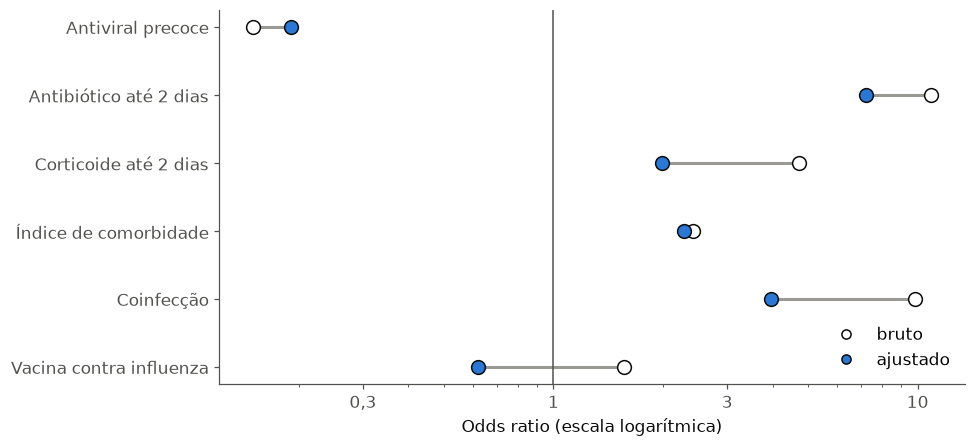

In [16]:
t2 = pd.DataFrame({
    "fator": ["Antiviral precoce", "Antibiótico até 2 dias", "Corticoide até 2 dias",
              "Índice de comorbidade", "Coinfecção", "Vacina contra influenza"],
    "bruto": [0.15, 10.87, 4.71, 2.42, 9.86, 1.56],
    "ajustado": [0.19, 7.23, 1.99, 2.29, 3.95, 0.62]})

fig, ax = plt.subplots(figsize=(9, 4.2))
for i, r_ in t2.iloc[::-1].reset_index(drop=True).iterrows():
    ax.plot([r_.bruto, r_.ajustado], [i, i], color=GRAY, lw=2, zorder=1)
    ax.plot(r_.bruto, i, "o", mfc="white", mec=INK, ms=9, zorder=3)
    ax.plot(r_.ajustado, i, "o", color=BLUE, mec=INK, ms=9, zorder=3)
ax.axvline(1, color=INK2, lw=1)
ax.set_yticks(range(len(t2)))
ax.set_yticklabels(t2.fator[::-1])
plain_log_x(ax, [0.1, 0.3, 1, 3, 10])
ax.set_xlabel("Odds ratio (escala logarítmica)")
ax.legend(handles=[Line2D([], [], marker="o", ls="", mfc="white", mec=INK, label="bruto"),
                   Line2D([], [], marker="o", ls="", color=BLUE, mec=INK, label="ajustado")],
          frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Figura 8.</b> Odds ratios brutos (círculos vazados) e ajustados (círculos cheios) da Tabela 2 de Huang et al. [1]. A vacina cruza a linha de nulidade após o ajuste.</div>

Chamar uma variável de confundidora exige mais do que ver o OR mudar com o ajuste: é preciso conhecer as relações causais entre exposição, desfecho e a variável. Uma medida de gravidade anterior ao tratamento, que influencia a prescrição e o prognóstico, é uma confundidora plausível. Uma variável que é consequência do tratamento ou da própria doença pode estar no caminho causal, e ajustar por ela responde a outra pergunta [10]. O artigo ajusta pelo uso de antibiótico nas primeiras 48 horas, que os próprios autores descrevem como possível marcador de gravidade; se o antibiótico reflete a mesma deterioração que leva à internação, o ajuste pode distorcer a estimativa em direção difícil de prever.

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 7 (seção 14). Desenhe as setas entre as três variáveis antes de responder.</div>

## 9. E-value

O ajuste só remove o confundimento pelas variáveis medidas. Os autores relatam um E-value de 10,0 para argumentar que um confundidor não medido dificilmente explicaria o achado [1].

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>E-value</b><br>O E-value é a menor intensidade de associação, na escala do risco relativo, que um confundidor não medido precisaria ter tanto com o tratamento quanto com o desfecho, condicionalmente às covariáveis medidas, para explicar completamente a associação observada. Para um RR maior ou igual a 1, vale $\mathrm{RR}+\sqrt{\mathrm{RR}(\mathrm{RR}-1)}$; um RR protetor é invertido antes do cálculo [11].</div>

**Proposição 4 (fator de viés e E-value).** Seja $U$ um fator binário não medido que multiplica o risco do desfecho por no máximo $\mathrm{RR}_{UY}$ em cada grupo de tratamento e cuja prevalência nos tratados é no máximo $\mathrm{RR}_{AU}$ vezes a prevalência nos não tratados, com ambos os limites maiores ou iguais a 1. Se o tratamento não tem efeito, o maior RR observado que $U$ pode produzir é o fator de viés

$$B=\frac{\mathrm{RR}_{AU}\,\mathrm{RR}_{UY}}{\mathrm{RR}_{AU}+\mathrm{RR}_{UY}-1}.$$

O menor valor comum de $\mathrm{RR}_{AU}$ e $\mathrm{RR}_{UY}$ para o qual $B$ iguala um RR observado maior ou igual a 1 é $\mathrm{RR}+\sqrt{\mathrm{RR}(\mathrm{RR}-1)}$.

*Demonstração (esboço).* Sem efeito do tratamento, com risco $r$ na ausência de $U$ e $\gamma=\mathrm{RR}_{UY}$, o risco nos tratados é $r(1+(\gamma-1)q_1)$ e nos não tratados $r(1+(\gamma-1)q_0)$, em que $q_1$ e $q_0$ são as prevalências de $U$. A razão entre os dois é o RR observado sob a hipótese nula. Com $q_1=\lambda q_0$ e $\lambda\le\mathrm{RR}_{AU}$, a razão é máxima quando $q_1=1$, e vale $\gamma\lambda/(\lambda+\gamma-1)$, que cresce em $\lambda$ e em $\gamma$; o máximo é $B$. Igualando $\mathrm{RR}_{AU}=\mathrm{RR}_{UY}=x$, obtém-se $B=x^2/(2x-1)$; igualar a RR e reorganizar dá $x^2-2\,\mathrm{RR}\,x+\mathrm{RR}=0$, cuja raiz maior é $\mathrm{RR}+\sqrt{\mathrm{RR}^2-\mathrm{RR}}$. ∎

A fórmula foi deduzida para a escala do RR. Os autores do método recomendam, para OR com desfecho comum (acima de 15%), converter antes: $\mathrm{RR}\approx\sqrt{\mathrm{OR}}$ quando não se conhece $p_0$ [11]. Neste estudo também se pode usar a correção de Zhang e Yu da seção 7, porque $p_0$ é conhecido. As duas conversões diferem porque a primeira é uma regra genérica e a segunda usa o risco observado.

In [17]:
def e_value(rr_):
    r_ = 1 / rr_ if rr_ < 1 else rr_          # a protective ratio is inverted first
    return r_ + math.sqrt(r_ * (r_ - 1))

print(f"OR 0,19 tratado como RR (artigo):    E = {br(e_value(0.19), 1)}")
print(f"RR ≈ raiz de OR = {br(math.sqrt(0.19))}:           E = {br(e_value(math.sqrt(0.19)), 1)}")
print(f"RR de Zhang e Yu = {br(zhang_yu(0.19, p0))}:          E = {br(e_value(zhang_yu(0.19, p0)), 1)}")

OR 0,19 tratado como RR (artigo):    E = 10,0
RR ≈ raiz de OR = 0,44:           E = 4,0
RR de Zhang e Yu = 0,35:          E = 5,2


O valor de 10,0 relatado corresponde a tratar o OR como se fosse RR. Com qualquer das duas conversões, o E-value fica entre 4 e 5. Um confundidor não medido precisaria estar associado ao antiviral precoce e à internação com RR de cerca de 4 a 5, cada um, para anular o achado. Ainda é uma associação robusta, mas bem menos blindada do que o número do artigo sugere. O E-value, além disso, não trata vieses de seleção nem de classificação da exposição (seção 12).

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 8 (seção 14). Decida primeiro se é preciso converter o OR.</div>

## 10. Número necessário para tratar

A última pergunta da introdução é quantas crianças como a do caso precisariam receber o antiviral para evitar uma internação.

<div style="background:#f1f1ef;border:1px solid #c9c8c3;border-radius:3px;padding:12px 16px;margin:14px 0;color:#111"><b>Número necessário para tratar</b><br>Para um tratamento, um comparador, uma população, um desfecho adverso e um horizonte de tempo especificados, o número necessário para tratar (NNT) é o inverso de uma redução absoluta de risco causal positiva. Expressa quantos tratados correspondem, em média, a um desfecho a menos em relação ao comparador [2,12].</div>

O NNT foi proposto como forma de expressar o efeito de um tratamento na escala do paciente [13]. A palavra "causal" importa: é preciso comparar os riscos que a mesma população teria sob as duas escolhas, o que um ensaio randomizado ou uma análise observacional bem justificada pode sustentar.

**Proposição 5 (da redução absoluta ao NNT).** Se os riscos na população-alvo sob tratamento e comparador são $p_1<p_0$, então a diferença esperada no número de eventos entre $m$ pacientes é $m(p_0-p_1)$. Consequentemente,

$$\mathrm{NNT}=\frac{1}{p_0-p_1}=\frac{1}{p_0(1-\mathrm{RR})}.$$

*Demonstração.* No comparador, $m$ pacientes contribuem com $mp_0$ eventos esperados; no tratamento, com $mp_1$. A subtração dá $m(p_0-p_1)$. Igualando essa diferença a um evento, obtém-se a primeira expressão; substituindo $p_1=p_0\mathrm{RR}$, a segunda. ∎

Este estudo não fornece o risco basal da criança do consultório; fornece o de uma coorte hospitalar selecionada. O NNT depende desse risco. Supondo, como cenário, que o RR de cerca de 0,35 se mantenha em outras populações, o bloco abaixo calcula o NNT para quatro riscos basais. O arredondamento é para cima, por convenção.

In [18]:
rr_assumed = 0.35
rows = []
for base in [0.01, 0.03, 0.10, 0.30]:
    arr = base * (1 - rr_assumed)
    rows.append({"risco basal": f"{br(100 * base, 0)}%",
                 "risco com antiviral precoce": f"{br(100 * base * rr_assumed)}%",
                 "redução absoluta": f"{br(100 * arr)} p.p.",
                 "NNT": math.ceil(1 / arr)})
pd.DataFrame(rows)

,risco basal,risco com antiviral precoce,redução absoluta,NNT
0,1%,"0,35%","0,65 p.p.",154
1,3%,"1,05%","1,95 p.p.",52
2,10%,"3,50%","6,50 p.p.",16
3,30%,"10,50%","19,50 p.p.",6


<div style="font-size:0.92em;color:#55544f;margin:4px 0 18px"><b>Tabela 4.</b> NNT para quatro riscos basais de internação, supondo RR constante de 0,35. Os riscos basais são cenários, não estimativas do estudo.</div>

O mesmo efeito relativo corresponde a um NNT de 154 quando o risco basal é de 1% e de 6 quando é de 30%. O NNT não é uma propriedade do medicamento: muda com o risco basal, o comparador, o desfecho e o período. Supor o RR constante entre populações é uma hipótese de cenário, não uma propriedade da divisão, e o intervalo de confiança do NNT deveria acompanhá-lo em uso clínico [12].

<div style="border-left:3px solid #1f5fa8;background:#f4f7fb;padding:9px 14px;margin:16px 0;color:#111"><b>Pratique.</b> Antes de continuar, resolva o Exercício 9 (seção 14). Informe sempre o risco basal junto com o NNT.</div>

## 11. De volta à decisão

As duas colegas tinham parte da razão.

A primeira acertou a direção: em todas as medidas, bruta ou ajustada, o antiviral precoce está associado a menos internação. Errou na magnitude e na generalização. Com 56% de internação no grupo de comparação, o desfecho não é raro, e o OR de 0,19 não significa 81% menos risco; o RR correspondente fica em torno de 0,35, uma redução próxima de 65% (seções 6 e 7). E um efeito relativo, sozinho, não justifica tratar toda criança com influenza: o benefício absoluto depende do risco basal (seção 10).

A segunda acertou o princípio: num caso-controle clássico não se estima risco (seção 5). Mas este estudo incluiu todas as crianças elegíveis, e na coorte hospitalar o RR pode ser calculado. O problema real não está no rótulo do desenho, e sim na seleção da população e na definição da exposição (seção 12).

O que se pode concluir: nesta coorte de crianças com influenza atendidas em hospitais de Taiwan, o antiviral precoce se associou a um risco de internação cerca de um terço do observado nas demais, com ajuste para as covariáveis medidas. O que não se pode concluir: o NNT para uma criança hígida atendida no pronto-socorro, nem que a associação seja integralmente causal.

Uma forma de comunicar o resultado à família, mais fiel aos dados do que "81% menos risco":

> Em crianças atendidas em hospital, as que começaram o antiviral nos dois primeiros dias internaram bem menos, algo como um terço das demais. Para uma criança saudável como a sua, o risco de internar já é baixo, então o ganho absoluto é pequeno; o medicamento costuma ser bem tolerado e, pelos dados, parece funcionar melhor quando iniciado cedo.

## 12. Aplicações em saúde: leitura crítica deste estudo

### Definição da exposição e causalidade reversa

O grupo de comparação reúne antiviral tardio e nenhum antiviral. Entre os internados, 28,8% receberam peramivir intravenoso e 20,1% terapia combinada, contra 3,9% e 1,7% entre os não internados [1]. O peramivir intravenoso é administrado no hospital. Parte das crianças, portanto, recebeu o antiviral depois de 48 horas porque foi internada, e foi classificada como "tardia". Nessa situação a internação causa a categoria de exposição, e não o contrário. A mediana entre o início do tratamento e a internação foi de 1,5 dia [1]. Os autores excluíram o peramivir em análise de sensibilidade, e a efetividade estimada ficou entre 80% e 82% [1]; o argumento reduz, mas não elimina, a preocupação, porque terapia oral iniciada no próprio atendimento que levou à internação segue o mesmo mecanismo.

### Confundimento por indicação

Os autores argumentam que o confundimento por indicação levaria a subestimar o efeito, porque o antiviral tenderia a ser prescrito às crianças mais graves [1]. A direção não é evidente. Crianças levadas ao médico nas primeiras 48 horas podem diferir das que chegam depois em acesso a serviços, gravidade inicial e velocidade de evolução, e essas diferenças podem favorecer o grupo precoce.

### Seleção e generalização

Os autores argumentam que os hospitais do estudo são grandes prestadores de atenção primária pediátrica na região e que a população é razoavelmente representativa [1]. Ainda assim, a coorte é de crianças com influenza confirmada em hospital, com 24% de internação, e 81% delas já recebiam antiviral precoce. Os resultados se aplicam com mais segurança a crianças semelhantes às do estudo do que à criança hígida da atenção primária, cujo risco basal é muito menor.

### Como o resultado deveria ser relatado

Com desfecho comum e a coorte completa disponível, o efeito poderia ter sido estimado diretamente como RR [9], acompanhado dos riscos absolutos nos dois grupos. O abstract, ao traduzir o OR ajustado como "81% lower risk", apresenta um efeito maior do que o dado sustenta.

## 13. Resumo

**Tabela dois por dois.** Organiza exposição (linhas) e desfecho (colunas) em quatro células, a, b, c e d. No estudo: 194, 1.012, 160 e 126.

**Risco e risco relativo.** O risco divide os eventos pelo grupo inteiro; o RR divide o risco dos expostos pelo dos não expostos. Na coorte do estudo, 16,1% contra 55,9%, RR 0,29.

**Odds e odds ratio.** A odds divide os eventos pelos não eventos; o OR é $ad/(bc)$. O OR bruto foi 0,15 e fica sempre mais longe de 1 do que o RR, pelo fator $(1-p_0)/(1-p_1)$, aqui 0,53.

**Estudo caso-controle.** As frações de amostragem se cancelam no OR, mas não nas proporções das linhas. Este estudo incluiu todos os elegíveis e funciona como coorte hospitalar.

**Suposição do desfecho raro.** O OR aproxima o RR apenas quando o risco é pequeno nos dois grupos da população de origem; com 56% no grupo de comparação, não se aplica.

**Conversão de OR em RR.** A correção de Zhang e Yu leva o OR ajustado de 0,19 a um RR de cerca de 0,35 (IC 95% 0,27-0,46), com a ressalva de que é aproximada para OR ajustado.

**Confundimento.** A vacina passou de OR 1,56 bruto a 0,62 ajustado, porque os vacinados tinham maior risco basal.

**E-value.** O 10,0 relatado trata o OR como RR; convertido, fica entre 4 e 5.

**Número necessário para tratar.** Com RR de 0,35, o NNT vai de 154 a 6 conforme o risco basal vai de 1% a 30%.

## 14. Exercícios

**Exercício 1.** Em um pronto-socorro, 1.000 lactentes com bronquiolite foram acompanhados por 72 horas. Quatrocentos receberam nebulização com salina hipertônica; 40 deles foram internados. Dos 600 que não receberam, 90 foram internados. Monte a tabela dois por dois, identificando a, b, c e d.

**Exercício 2.** Com a tabela do Exercício 1, calcule o risco de internação em cada grupo, o RR e a redução relativa do risco.

**Exercício 3.** Ainda com a mesma tabela, calcule o OR. Use a Proposição 1 para explicar por que, aqui, OR e RR ficaram próximos.

**Exercício 4.** Um estudo caso-controle sobre síndrome da morte súbita do lactente incluiu 50 casos e 200 controles. Trinta casos e 40 controles dormiam de bruços. (a) Calcule o OR. (b) Que medidas não podem ser calculadas, e por quê? (c) Se os pesquisadores tivessem recrutado 400 controles, com a mesma proporção de expostos, o que aconteceria com o OR?

**Exercício 5.** Para cada cenário, decida se o OR pode ser lido como RR, calculando o fator $(1-p_0)/(1-p_1)$: (a) um estudo de profilaxia em que a infecção ocorre em 2% dos não tratados e 1% dos tratados; (b) um estudo em que o desfecho ocorre em 30% dos não expostos e 15% dos expostos.

**Exercício 6.** Um estudo em pronto-socorro relata OR de 3,0 para febre acima de 39 °C e bacteremia, numa população em que o risco de bacteremia sem febre alta é de 30%. Estime o RR pela correção de Zhang e Yu e comente a interpretação.

**Exercício 7.** Um estudo relata OR bruto de 1,8 para uso de chupeta e otite média aguda recorrente. Após ajuste para frequência a creche, o OR cai para 1,1. Explique o que provavelmente aconteceu, nomeando o conceito.

**Exercício 8.** Calcule o E-value para (a) um RR de 0,5 e (b) um OR de 0,5 obtido com desfecho comum, sem conhecer o risco basal.

**Exercício 9.** Suponha RR de 0,35 para o antiviral precoce. Calcule o NNT para uma criança com risco basal de internação de 3% e para outra com risco de 30%.

As soluções estão na seção 15. O bloco abaixo resolve os Exercícios 2 e 3 e pode ser usado como calculadora para os demais.

In [19]:
def two_by_two(a_, b_, c_, d_):
    # a = exposed with outcome, b = exposed without, c = unexposed with, d = unexposed without
    p1_, p0_ = a_ / (a_ + b_), c_ / (c_ + d_)
    rr_, or_ = p1_ / p0_, (a_ * d_) / (b_ * c_)
    print(f"p1 = {br(p1_, 3)}   p0 = {br(p0_, 3)}")
    print(f"RR = {br(rr_)}   RRR = {1 - rr_:.0%}   OR = {br(or_)}")
    print(f"fator (1-p0)/(1-p1) = {br((1 - p0_) / (1 - p1_), 3)}")

two_by_two(40, 360, 90, 510)

p1 = 0,100   p0 = 0,150
RR = 0,67   RRR = 33%   OR = 0,63
fator (1-p0)/(1-p1) = 0,944


## 15. Soluções dos exercícios

Tente resolver cada exercício antes de ler a solução.

**Exercício 1.** Exposição nas linhas, desfecho nas colunas: a = 40 (salina e internado), b = 360 (salina e não internado), c = 90 (sem salina e internado), d = 510 (sem salina e não internado).

**Exercício 2.** $p_1=40/400=0{,}10$ e $p_0=90/600=0{,}15$. RR = 0,67; redução relativa de 33%.

**Exercício 3.** $\mathrm{OR}=(40\times510)/(360\times90)=0{,}63$. O fator $(1-0{,}15)/(1-0{,}10)=0{,}944$ é próximo de 1 porque os dois riscos são baixos; $0{,}67\times0{,}944=0{,}63$. Com riscos de 40% e 60%, OR e RR se afastariam muito mais.

**Exercício 4.** (a) Os controles não expostos são 160 e os casos não expostos, 20: $\mathrm{OR}=(30\times160)/(40\times20)=6{,}0$. (b) Não se calculam risco, RR, redução absoluta nem NNT, porque a proporção de casos na amostra (50 de 250) foi fixada pelos pesquisadores (seção 5). Como a síndrome é muito rara na população, o OR aproxima bem o RR. (c) O OR não muda: $(30\times320)/(80\times20)=6{,}0$, como prevê a Proposição 2.

**Exercício 5.** (a) $(1-0{,}02)/(1-0{,}01)=0{,}99$: o OR pode ser lido como RR. (b) $(1-0{,}30)/(1-0{,}15)=0{,}82$: o OR está 18% mais longe de 1 do que o RR e não deve ser lido como RR.

**Exercício 6.** $\mathrm{RR}\approx3{,}0/(0{,}70+0{,}30\times3{,}0)=3{,}0/1{,}60=1{,}9$. Com desfecho comum e OR maior que 1, o OR exagera a associação para cima. Se o OR fosse ajustado, a conversão seria apenas aproximada (seção 7).

**Exercício 7.** Confundimento pela frequência a creche: a creche se associa ao uso de chupeta e, por maior exposição a vírus respiratórios, à otite. Parte da associação bruta refletia a creche. Para chamá-la de confundidora é preciso sustentar que ela não é consequência do uso de chupeta.

**Exercício 8.** (a) Invertendo, 2,0; $E=2{,}0+\sqrt{2{,}0\times1{,}0}=3{,}41$. (b) Com desfecho comum, $\mathrm{RR}\approx\sqrt{0{,}5}=0{,}707$; invertendo, 1,414; $E=1{,}414+\sqrt{1{,}414\times0{,}414}=2{,}18$.

**Exercício 9.** Risco de 3%: redução absoluta $0{,}03\times0{,}65=0{,}0195$, NNT = 52 (51,3 arredondado para cima). Risco de 30%: redução $0{,}195$, NNT = 6 (5,1 arredondado para cima).

## Leituras complementares

- Davies, Crombie e Tavakoli [4]: quando o odds ratio engana, com exemplos numéricos.
- Pearce [5] e Kerr e colaboradores [6]: o que o odds ratio estima em cada tipo de caso-controle.
- Hernán e Robins [10], capítulos 7 e 8: confundimento e seleção em linguagem causal.
- Monaghan e colaboradores [3]: tutorial sobre OR, RR, risco absoluto e NNT.

## Referências

1. Huang YN, Chang CJ, Dai YL, Kung YH, Huang CY, Huang DTN, et al. Early antiviral therapy in pediatric outpatients and risk of influenza-related hospitalization. Pediatrics. 2026;158(3):e2025075020. doi:10.1542/peds.2025-075020
2. Kirkwood BR, Sterne JAC. Essential medical statistics. 2nd ed. Oxford: Blackwell Science; 2003.
3. Monaghan TF, Rahman SN, Agudelo CW, Wein AJ, Lazar JM, Everaert K, et al. Foundational statistical principles in medical research: a tutorial on odds ratios, relative risk, absolute risk, and number needed to treat. Int J Environ Res Public Health. 2021;18(11):5669. doi:10.3390/ijerph18115669
4. Davies HTO, Crombie IK, Tavakoli M. When can odds ratios mislead? BMJ. 1998;316(7136):989-91. doi:10.1136/bmj.316.7136.989
5. Pearce N. What does the odds ratio estimate in a case-control study? Int J Epidemiol. 1993;22(6):1189-92. doi:10.1093/ije/22.6.1189
6. Kerr S, Greenland S, Jeffrey K, Millington T, Bedston S, Ritchie L, et al. Understanding and reporting odds ratios as rate-ratio estimates in case-control studies. J Glob Health. 2023;13:04101. doi:10.7189/jogh.13.04101
7. Knol MJ, Vandenbroucke JP, Scott P, Egger M. What do case-control studies estimate? Survey of methods and assumptions in published case-control research. Am J Epidemiol. 2008;168(9):1073-81. doi:10.1093/aje/kwn217
8. Zhang J, Yu KF. What's the relative risk? A method of correcting the odds ratio in cohort studies of common outcomes. JAMA. 1998;280(19):1690-1. doi:10.1001/jama.280.19.1690
9. McNutt LA, Wu C, Xue X, Hafner JP. Estimating the relative risk in cohort studies and clinical trials of common outcomes. Am J Epidemiol. 2003;157(10):940-3. doi:10.1093/aje/kwg074
10. Hernán MA, Robins JM. Causal inference: what if. Boca Raton: Chapman & Hall/CRC; 2020.
11. VanderWeele TJ, Ding P. Sensitivity analysis in observational research: introducing the E-value. Ann Intern Med. 2017;167(4):268-74. doi:10.7326/M16-2607
12. Chesnaye NC, Ortiz A, van Diepen M, Dekker F, Zoccali C, Tripepi G, et al. How to interpret the number needed to treat for clinicians. Nephrol Dial Transplant. 2026;41(3):437-44. doi:10.1093/ndt/gfaf168
13. Laupacis A, Sackett DL, Roberts RS. An assessment of clinically useful measures of the consequences of treatment. N Engl J Med. 1988;318(26):1728-33. doi:10.1056/NEJM198806303182605